<a href="https://colab.research.google.com/github/dave-heslop74/EMSC2010-W7-P1/blob/main/EMSC2010_W7_P1_NB1_uXXXXXXX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W7-P1-NB1

We will test if the air pressures inside and outside the building are the same.

The whole class will collect data using Phyphox, with each person measuring one inside pressure and one outside pressure. These data will be our samples.

Import the packages we need including:

* ```PyMC``` used for *probabilistic programming*
* ```Arviz``` used for exploratory analysis of Bayesian models

In [11]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["axes.formatter.useoffset"] = False #this forces Matplotlib to show full values on the axes.

### Phase 0: Input data
We'll type in our data as a ```numpy``` array.

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
# Class air pressure measurements (in hPa)
rng = np.random.default_rng(42)
outside = rng.normal(1013.5, 0.8, 30)

### Phase 1: Prior predictive distribution

Before we look at any data, we describe what we already believe. This is the **prior** distribution.

We then ask: if our prior beliefs are correct, what data would we expect to see

This is called the **prior predictive** distribution.

In PyMC we don't calculate an analytical form for the distributions. Rather the distribution are *sampled* using Monte Carlo.

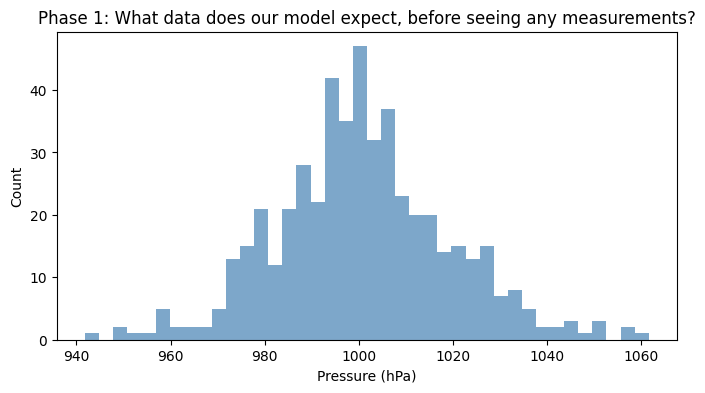

In [16]:
with pm.Model() as model: #setup a prior in PyMC

    # The prior is our belief about the true mean pressure, before seeing any data.
    # We think it is around 1000 hPa,
    # and we allow quite a wide spread of 10 hPa to reflect our uncertainty.
    mu = pm.Normal("mu", mu=1000, sigma=20)

    # Our belief about the stnadard deviation of individual measurements.
    # HalfNormal means we only allow positive values (spread can't be negative).
    # sigma=2 means we expect most measurement noise to be within 2 hPa.
    sigma = pm.HalfNormal("sigma", sigma=3)

    # The data generating process:
    # Each measurement is drawn from a Normal distribution
    # centred on the true mean, with the measurement spread.
    # observed=None means we are not fitting to data yet —
    # we are asking the model to generate samples from the prior.
    obs = pm.Normal("obs", mu=mu, sigma=sigma)

    # Draw samples from the prior — no real data involved at this stage
    prior_samples = pm.sample_prior_predictive(500)

# Plot the data the model expects before seeing any real measurements.
# If this looks unreasonable we should adjust our prior beliefs before proceeding.
plt.figure(figsize=(8, 4))
plt.hist(prior_samples.prior["obs"].values.flatten(),
         bins=40, color="steelblue", alpha=0.7)
plt.xlabel("Pressure (hPa)")
plt.ylabel("Count")
plt.title("Phase 1: What data does our model expect, before seeing any measurements?")

### Phase 2: Sample the posterior

Now we bring in the measured data. The model is identical to Phase 1 — the only change is we now include the data with ```observed=outside```.

This changes the model from *generative* (simulating data from beliefs) to *inferential* (updating beliefs from data).

The result is the sampled **posterior** distribution.

Output()

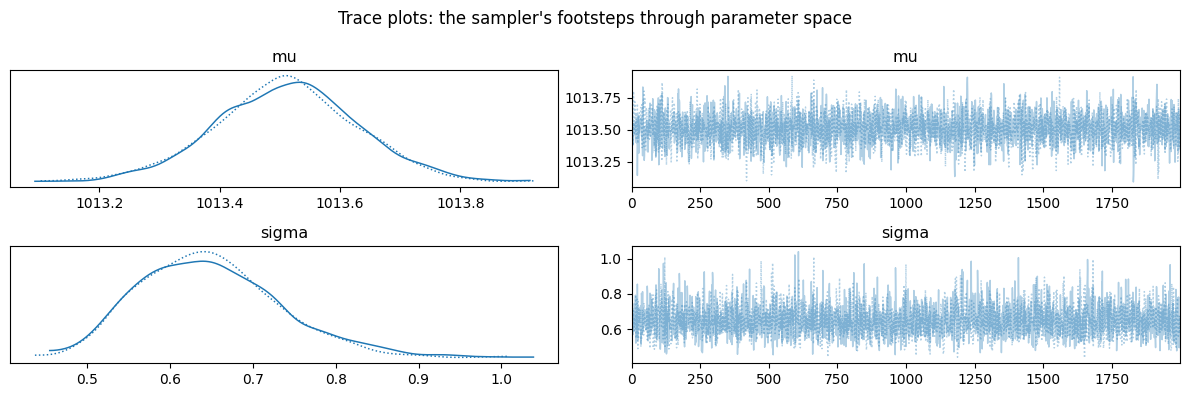

In [17]:
with pm.Model() as model:

    # Same prior as before
    mu    = pm.Normal("mu", mu=1013, sigma=5)
    sigma = pm.HalfNormal("sigma", sigma=2)

    # The only change: observed=outside tells the model to fit to real data.
    # The model now asks: what values of mu and sigma make
    # these observations most probable?
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=outside)

    # Run the sampler.
    # The sampler explores the space of possible mu and sigma values,
    # spending more time in regions that are consistent with the data.
    # The collection of samples traces out the posterior distribution.
    trace = pm.sample(2000, return_inferencedata=True, progressbar=True)


# ── Inspect the Sampler ────────────────────────────────────────────────────────
# The trace plot shows the sampler's path over time.
# A healthy trace looks like random noise around a stable value —
# this means the sampler has found the posterior and is exploring it well.
# If you see trends or the chains drifting, something may be wrong.
az.plot_trace(trace, var_names=["mu", "sigma"])
plt.suptitle("Trace plots: the sampler's footsteps through parameter space")
plt.tight_layout()

### Phase 3: Visualize the results

We can now obtain the samples of the posterior and plot them as a distribution.

We can also compare the prior and posterior to see how much we have learned from the data.

Number of samples:  4000
Posterior mean:     1013.511 hPa
Posterior std:      0.118 hPa
95% HDI:            [1013.28320437 1013.75041526]


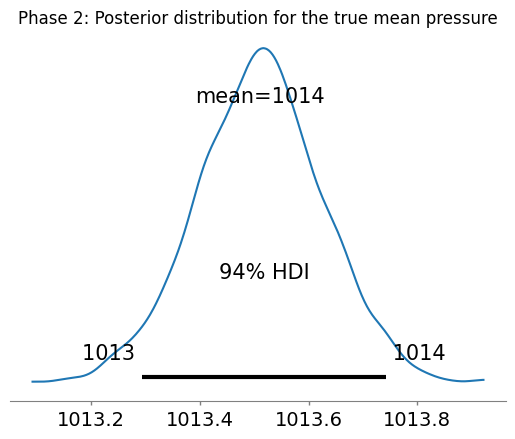

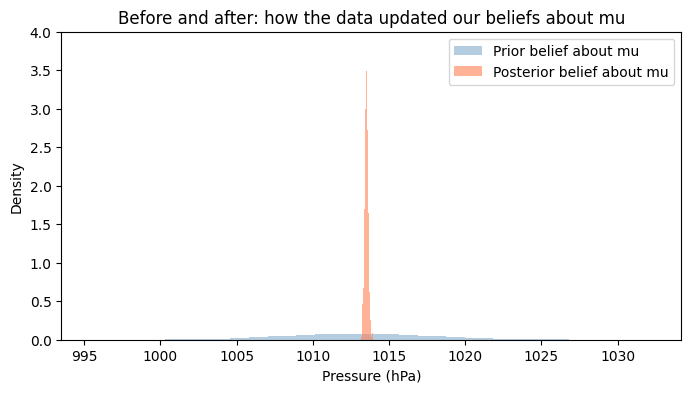

In [18]:
# ── Extract and Summarise the Posterior for mu ────────────────────────────────
# Pull out the samples for mu as a simple array of numbers.
# Each number is a plausible value of the true mean pressure,
# given everything the model has learned from the data.
mu_samples = trace.posterior["mu"].values.flatten()

print(f"Number of samples:  {len(mu_samples)}")
print(f"Posterior mean:     {mu_samples.mean():.3f} hPa")
print(f"Posterior std:      {mu_samples.std():.3f} hPa")
print(f"95% HDI:            {az.hdi(mu_samples, hdi_prob=0.95)}")

# Plot the posterior for mu.
# This is our updated belief about the true mean pressure
# after incorporating all 30 measurements.
# The shaded region is the 95% Highest Density Interval (HDI):
# we are 95% confident the true mean lies within this range.
az.plot_posterior(trace, var_names=["mu"])
plt.title("Phase 2: Posterior distribution for the true mean pressure")
plt.show()


# ── Before and After ──────────────────────────────────────────────────────────
# Plot the prior and posterior for mu side by side
# so students can see how the data has updated our beliefs.
mu_range = np.linspace(1005, 1022, 300)

prior_mu = pm.draw(pm.Normal.dist(mu=1013, sigma=5), draws=10000)

plt.figure(figsize=(8, 4))
plt.hist(prior_mu, bins=60, density=True,
         alpha=0.4, color="steelblue", label="Prior belief about mu")
plt.hist(mu_samples, bins=60, density=True,
         alpha=0.6, color="coral", label="Posterior belief about mu")
plt.xlabel("Pressure (hPa)")
plt.ylabel("Density")
plt.title("Before and after: how the data updated our beliefs about mu")
plt.legend()

Importantly, we'll now store the posterior samples in a variable named specifically for the outside pressures.

In [19]:
output_posterior = mu_samples

### Now it's your turn.

Make a copy of the data input, sampling, and plotting code from above to estimate the posterior distribution for the inside pressures.

**Important** - don't simply change the code above. Rather make a copy of the code, paste it below and make your edits there. This means you will have a version of the code for outside pressures and a version of the code for inside pressures.